In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr

# Numerical differentiation

In [2]:
def central_numerical_differentiation(a, t):
    a = np.asarray(a)
    t = np.asarray(t)
    da = np.zeros(len(a)) 

    da[1:-1] = (a[2:] - a[:-2]) / (t[2:] - t[:-2])

    
    da[0] = (a[1] - a[0]) / (t[1] - t[0]) #forward
    da[-1] = (a[-1] - a[-2]) / (t[-1] - t[-2]) #backward

    return da

## Vehicle1

In [3]:
df = pd.read_excel("dev2_combined_365bags_2025-02-23_07-10-45_2025-02-23_13-15-31_CET.xlsx")

In [4]:
data = df[["timestamp (1740291045,1740312931) [unix]","velocity (0,200) [km/h]", "acceleration_magnitude_no_gravity (0,50) [m/s虏]"]].copy()

In [49]:
data = data.rename(columns={"timestamp (1740291045,1740312931) [unix]" : "timestamp",
                            "velocity (0,200) [km/h]" : "velocity",
                           "acceleration_magnitude_no_gravity (0,50) [m/s虏]" : "acc_magnitude_no_gravity"})

In [6]:
ss3_v1 = data.loc[190521:194040].copy()

In [7]:
ss3_v1["time"] = ss3_v1["timestamp"] - ss3_v1["timestamp"].iloc[0]
ss3_v1["dt"] = ss3_v1["timestamp"].diff()
print(ss3_v1["dt"].describe())
print(ss3_v1["dt"].value_counts().sort_index())

count    3519.000000
mean        0.100199
std         0.006076
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max         0.400000
Name: dt, dtype: float64
dt
0.1    2110
0.1    1404
0.2       4
0.4       1
Name: count, dtype: int64


In [8]:
"""
print(ss3_v1[[    # checking for nul values.... 16 acc magnitude no gravity
    "timestamp",
    "velocity",
    "acc_magnitude_no_gravity"
]].isna().sum())
"""

'\nprint(ss3_v1[[    # checking for nul values.... 16 acc magnitude no gravity\n    "timestamp",\n    "velocity",\n    "acc_magnitude_no_gravity"\n]].isna().sum())\n'

In [9]:
ss3_v1["acc_magnitude_no_gravity"] = ss3_v1["acc_magnitude_no_gravity"].interpolate()

In [10]:
#print(ss3_v1["acc_magnitude_no_gravity"].dtype)

In [11]:
t = ss3_v1["timestamp"].to_numpy()
a = ss3_v1["acc_magnitude_no_gravity"].to_numpy()

ss3_v1["jerk"] = central_numerical_differentiation(a, t)

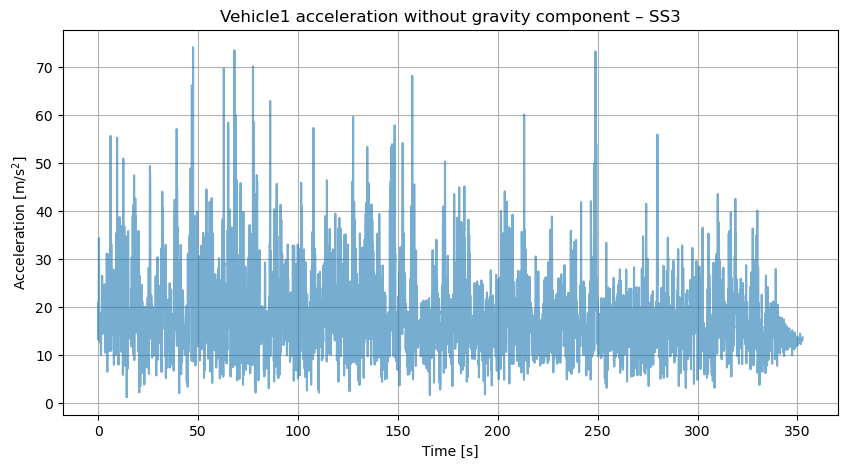

In [12]:
ss3_v1["time_rel"] = ss3_v1["timestamp"] - ss3_v1["timestamp"].iloc[0]

plt.figure(figsize=(10,5))
plt.plot(ss3_v1["time_rel"], ss3_v1["acc_magnitude_no_gravity"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
plt.title("Vehicle1 acceleration without gravity component – SS3")
plt.grid()
plt.show()

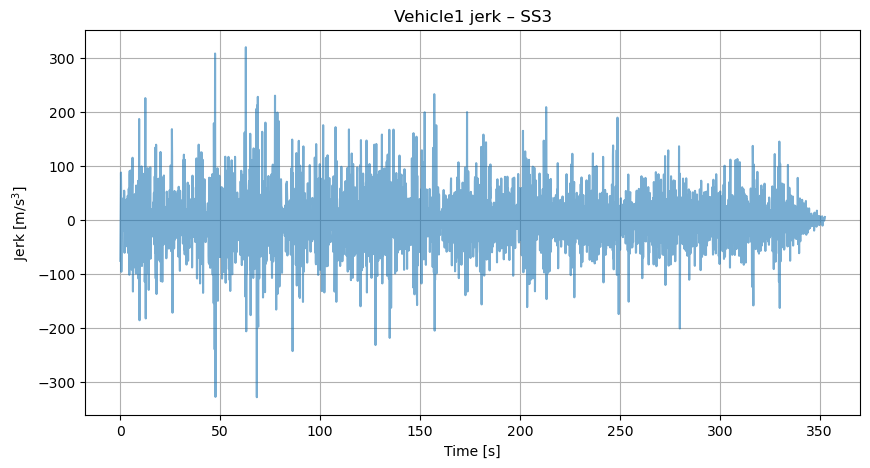

In [13]:
plt.figure(figsize=(10,5))
plt.plot(ss3_v1["time_rel"], ss3_v1["jerk"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Jerk [$\mathrm{m/s^3}$]")
plt.title("Vehicle1 jerk – SS3")
plt.grid()
plt.show()

In [14]:
#print(ss3_v1["velocity"].dtype)
ss3_v1["velocity"] = pd.to_numeric(ss3_v1["velocity"], errors = "coerce")
ss3_v1["velocity [m/s]"] = ss3_v1["velocity"] / 3.6 

In [15]:
print(ss3_v1[["velocity [m/s]", "acc_magnitude_no_gravity", "jerk"]].describe())

       velocity [m/s]  acc_magnitude_no_gravity         jerk
count     3517.000000               3520.000000  3520.000000
mean        23.690675                 18.366050    -0.031685
std          7.809916                  8.752145    54.143185
min          0.205556                  1.180000  -328.250313
25%         18.572222                 12.780000   -30.812520
50%         24.436111                 16.710000    -0.400000
75%         29.683333                 22.090000    30.400002
max         39.097222                 74.150000   319.700305


## Vehicle2

In [16]:
df_2 = pd.read_excel("dev_3_combined_447bags_2025-02-23_07-06-09_2025-02-23_14-32-35_CET.xlsx")

In [17]:
data_2 = df_2[["timestamp (1740290769,1740317555) [unix]","velocity (0,200) [km/h]", "acceleration_magnitude_no_gravity (0,50) [m/s虏]"]].copy()

In [18]:
data_2 = data_2.rename(columns={"timestamp (1740290769,1740317555) [unix]" : "timestamp",
                           "velocity (0,200) [km/h]" : "velocity",
                           "acceleration_magnitude_no_gravity (0,50) [m/s虏]" : "acc_magnitude_no_gravity"})

In [19]:
ss3_v2 = data_2.loc[167378:170629].copy()

In [20]:
ss3_v2["time"] = ss3_v2["timestamp"] - ss3_v2["timestamp"].iloc[0]
ss3_v2["dt"] = ss3_v2["timestamp"].diff()
print(ss3_v2["dt"].describe())
print(ss3_v2["dt"].value_counts().sort_index())

count    3251.00000
mean        0.10040
std         0.01037
min         0.10000
25%         0.10000
50%         0.10000
75%         0.10000
max         0.40000
Name: dt, dtype: float64
dt
0.1    1948
0.1    1298
0.3       2
0.4       3
Name: count, dtype: int64


In [21]:
"""
print(ss3_v2[[    # checking for nul values.... 5 acc magnitude no gravity
    "timestamp",
    "velocity",
    "acc_magnitude_no_gravity"
]].isna().sum())
"""

'\nprint(ss3_v2[[    # checking for nul values.... 5 acc magnitude no gravity\n    "timestamp",\n    "velocity",\n    "acc_magnitude_no_gravity"\n]].isna().sum())\n'

In [22]:
ss3_v2["acc_magnitude_no_gravity"] = ss3_v2["acc_magnitude_no_gravity"].interpolate()

In [23]:
#print(ss3_v2["acc_magnitude_no_gravity"].dtype)

In [24]:
t = ss3_v2["timestamp"].to_numpy()
a = ss3_v2["acc_magnitude_no_gravity"].to_numpy()

ss3_v2["jerk"] = central_numerical_differentiation(a, t)

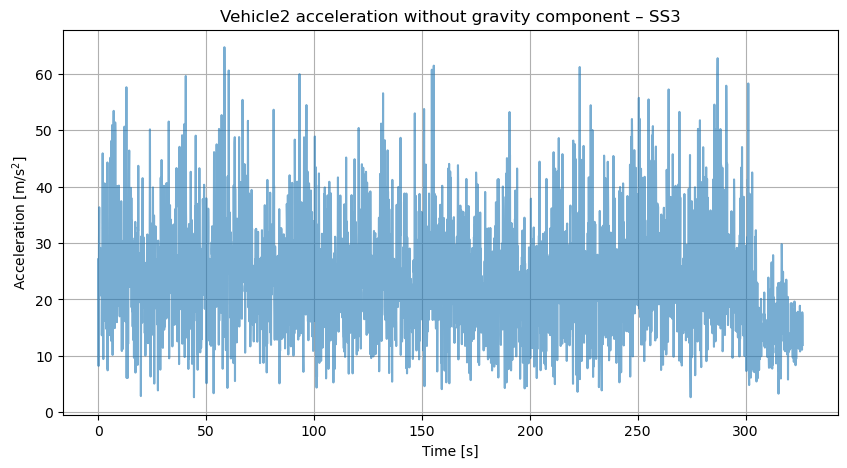

In [25]:
ss3_v2["time_rel"] = ss3_v2["timestamp"] - ss3_v2["timestamp"].iloc[0]

plt.figure(figsize=(10,5))
plt.plot(ss3_v2["time_rel"], ss3_v2["acc_magnitude_no_gravity"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
plt.title("Vehicle2 acceleration without gravity component – SS3")
plt.grid()
plt.show()

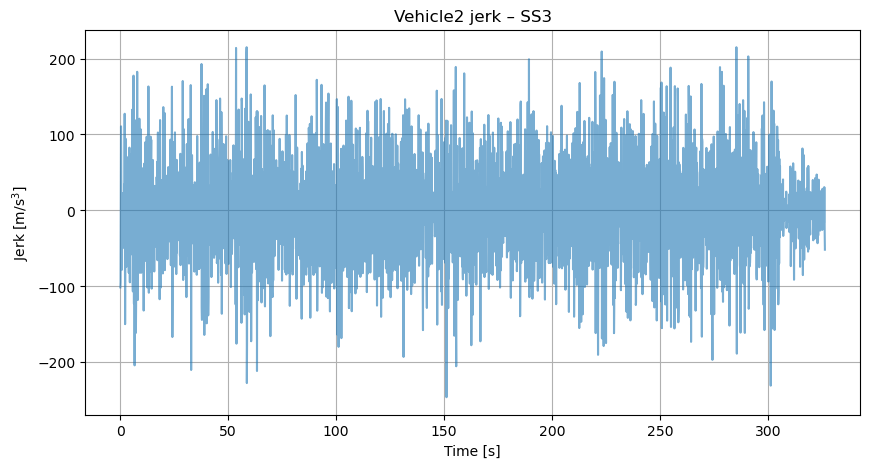

In [26]:
plt.figure(figsize=(10,5))
plt.plot(ss3_v2["time_rel"], ss3_v2["jerk"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Jerk [$\mathrm{m/s^3}$]")
plt.title("Vehicle2 jerk – SS3")
plt.grid()
plt.show()

In [27]:
print(ss3_v2["velocity"].dtype)
ss3_v2["velocity"] = pd.to_numeric(ss3_v2["velocity"], errors = "coerce")
ss3_v2["velocity [m/s]"] = ss3_v2["velocity"] / 3.6 

object


In [28]:
print(ss3_v2[["velocity [m/s]", "acc_magnitude_no_gravity", "jerk"]].describe())

       velocity [m/s]  acc_magnitude_no_gravity         jerk
count     3252.000000               3252.000000  3252.000000
mean        25.574065                 23.946950    -0.130437
std          9.475356                  9.871831    64.490598
min          0.258333                  2.650000  -245.899941
25%         19.291667                 16.810000   -40.412502
50%         26.544444                 23.220000    -1.625001
75%         32.308333                 29.642500    38.775025
max         47.019444                 64.750000   214.849949


## Vehicle3

In [29]:
df_3 = pd.read_excel("dev_4_3_combined_372bags_2025-02-23_08-28-03_2025-02-23_14-39-30_CET.xlsx")

In [30]:
data_3 = df_3[["timestamp (1740295683,1740317970) [unix]","velocity (0,200) [km/h]", "acceleration_magnitude_no_gravity (0,50) [m/s虏]"]].copy()

In [31]:
data_3 = data_3.rename(columns={"timestamp (1740295683,1740317970) [unix]" : "timestamp",
                           "velocity (0,200) [km/h]" : "velocity",
                           "acceleration_magnitude_no_gravity (0,50) [m/s虏]" : "acc_magnitude_no_gravity"})

In [32]:
ss3_v3 = data_3.loc[124106:127277].copy()

In [33]:
ss3_v3["time"] = ss3_v3["timestamp"] - ss3_v3["timestamp"].iloc[0]
ss3_v3["dt"] = ss3_v3["timestamp"].diff()
print(ss3_v3["dt"].describe())
print(ss3_v3["dt"].value_counts().sort_index())

count    3.171000e+03
mean     1.000000e-01
std      1.168131e-07
min      9.999990e-02
25%      9.999990e-02
50%      9.999990e-02
75%      1.000001e-01
max      1.000001e-01
Name: dt, dtype: float64
dt
0.1    1903
0.1    1268
Name: count, dtype: int64


In [34]:
"""
print(ss3_v3[[    # checking for nul values.... 4 acc magnitude no gravity
    "timestamp",
    "velocity",
    "acc_magnitude_no_gravity"
]].isna().sum())
"""

'\nprint(ss3_v3[[    # checking for nul values.... 4 acc magnitude no gravity\n    "timestamp",\n    "velocity",\n    "acc_magnitude_no_gravity"\n]].isna().sum())\n'

In [35]:
ss3_v3["acc_magnitude_no_gravity"] = ss3_v3["acc_magnitude_no_gravity"].interpolate()

In [36]:
#print(ss3_v3["acc_magnitude_no_gravity"].dtype)

In [37]:
t = ss3_v3["timestamp"].to_numpy()
a = ss3_v3["acc_magnitude_no_gravity"].to_numpy()

ss3_v3["jerk"] = central_numerical_differentiation(a, t)

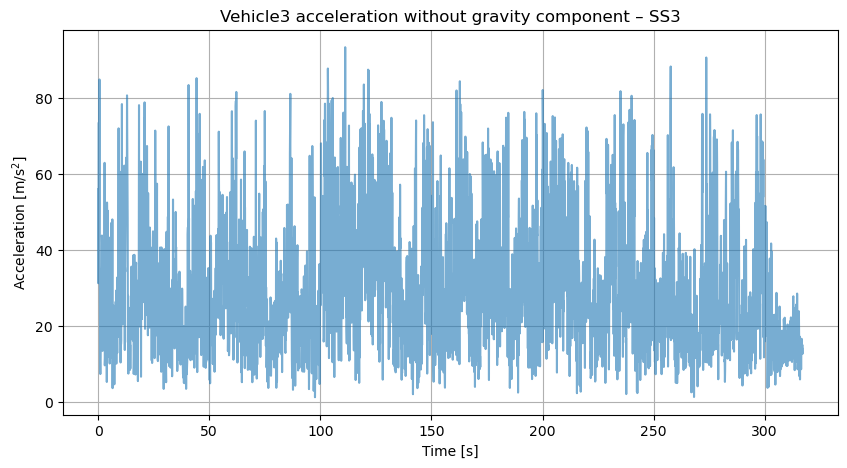

In [38]:
ss3_v3["time_rel"] = ss3_v3["timestamp"] - ss3_v3["timestamp"].iloc[0]

plt.figure(figsize=(10,5))
plt.plot(ss3_v3["time_rel"], ss3_v3["acc_magnitude_no_gravity"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
plt.title("Vehicle3 acceleration without gravity component – SS3")
plt.grid()
plt.show()

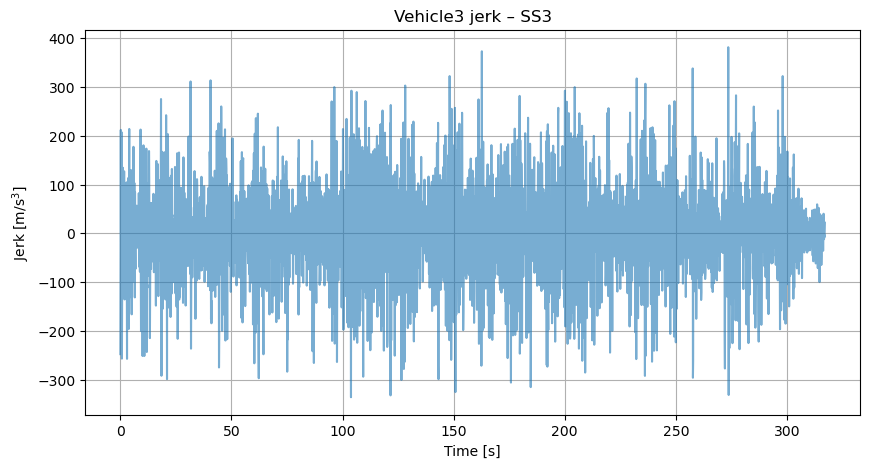

In [39]:
plt.figure(figsize=(10,5))
plt.plot(ss3_v3["time_rel"], ss3_v3["jerk"], alpha = 0.6)
plt.xlabel("Time [s]")
plt.ylabel(r"Jerk [$\mathrm{m/s^3}$]")
plt.title("Vehicle3 jerk – SS3")
plt.grid()
plt.show()

In [40]:
#print(ss3_v3["velocity"].dtype)
ss3_v3["velocity"] = pd.to_numeric(ss3_v3["velocity"], errors = "coerce")
ss3_v3["velocity [m/s]"] = ss3_v3["velocity"] / 3.6 

In [41]:
print(ss3_v3[["velocity [m/s]", "acc_magnitude_no_gravity", "jerk"]].describe())

       velocity [m/s]  acc_magnitude_no_gravity         jerk
count     3172.000000               3172.000000  3172.000000
mean        26.195733                 30.224628    -0.165369
std          8.275069                 17.456067   100.452029
min          5.813889                  1.260000  -335.499920
25%         19.961111                 16.762500   -58.162538
50%         26.955556                 26.265000     0.400000
75%         32.461111                 40.555000    59.512486
max         43.366667                 93.470000   381.049909


## Vehicle jerk comparison 

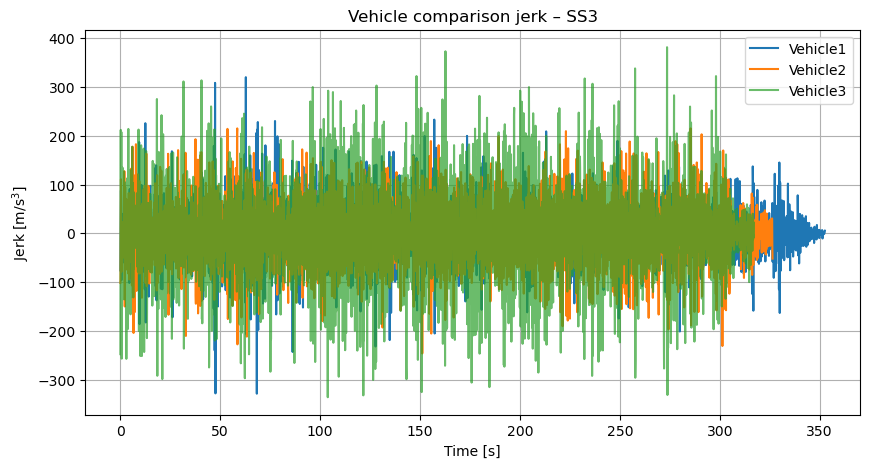

In [42]:
plt.figure(figsize=(10,5))

plt.plot(ss3_v1["time_rel"], ss3_v1["jerk"], label = "Vehicle1")
plt.plot(ss3_v2["time_rel"], ss3_v2["jerk"], label = "Vehicle2")
plt.plot(ss3_v3["time_rel"], ss3_v3["jerk"], label = "Vehicle3", alpha = 0.7)

plt.xlabel("Time [s]")
plt.ylabel(r"Jerk [$\mathrm{m/s^3}$]")
plt.title("Vehicle comparison jerk – SS3")
plt.legend()
plt.grid()
plt.show()

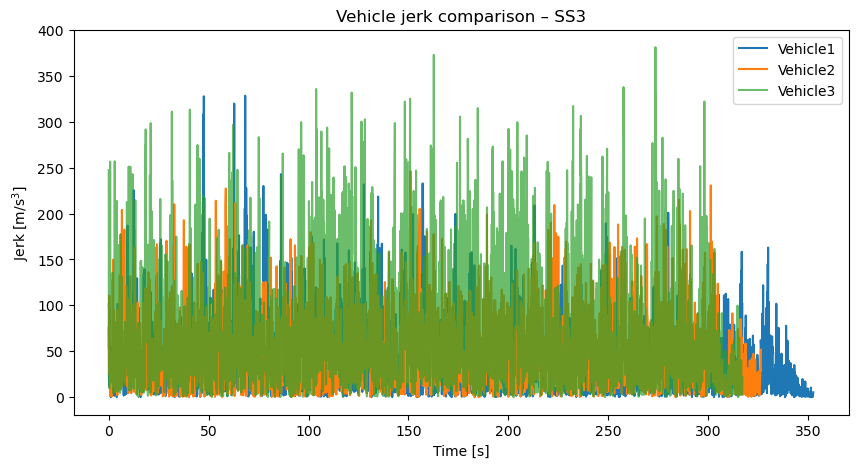

In [43]:
plt.figure(figsize=(10,5))

plt.plot(ss3_v1["time_rel"], np.abs(ss3_v1["jerk"]), label = "Vehicle1")
plt.plot(ss3_v2["time_rel"], np.abs(ss3_v2["jerk"]), label = "Vehicle2")
plt.plot(ss3_v3["time_rel"], np.abs(ss3_v3["jerk"]), label = "Vehicle3", alpha = 0.7)

plt.xlabel("Time [s]")
plt.ylabel(r"Jerk [$\mathrm{m/s^3}$]")
plt.title("Vehicle jerk comparison – SS3")
plt.legend()
plt.grid(True)
plt.grid()
plt.show()

In [44]:
for name, df in [("Vehicle1", ss3_v1), ("Vehicle2", ss3_v2), ("Vehicle3", ss3_v3)]:
    valid = df[["acc_magnitude_no_gravity", "jerk"]].dropna()
    r, p = pearsonr(valid["acc_magnitude_no_gravity"], np.abs(valid["jerk"]))

    print(name)
    print("Pearson r:", r)
    print("p-value:", p)

Vehicle1
Pearson r: 0.15697352635453693
p-value: 7.392198681764597e-21
Vehicle2
Pearson r: 0.12743789638950875
p-value: 3.0026742494466505e-13
Vehicle3
Pearson r: 0.20758204504058245
p-value: 3.248330567124339e-32


In [45]:
for name, df in [("Vehicle1", ss3_v1), ("Vehicle2", ss3_v2), ("Vehicle3", ss3_v3)]:
    valid = df[["velocity", "jerk"]].dropna()
    r, p = pearsonr(valid["velocity"], np.abs(valid["jerk"]))

    print(name)
    print("Pearson r:", r)
    print("p-value:", p)

Vehicle1
Pearson r: 0.040564188225900424
p-value: 0.016138607504161944
Vehicle2
Pearson r: 0.021967500977966087
p-value: 0.21042595798435318
Vehicle3
Pearson r: 0.14055535751164797
p-value: 1.8273099437660008e-15


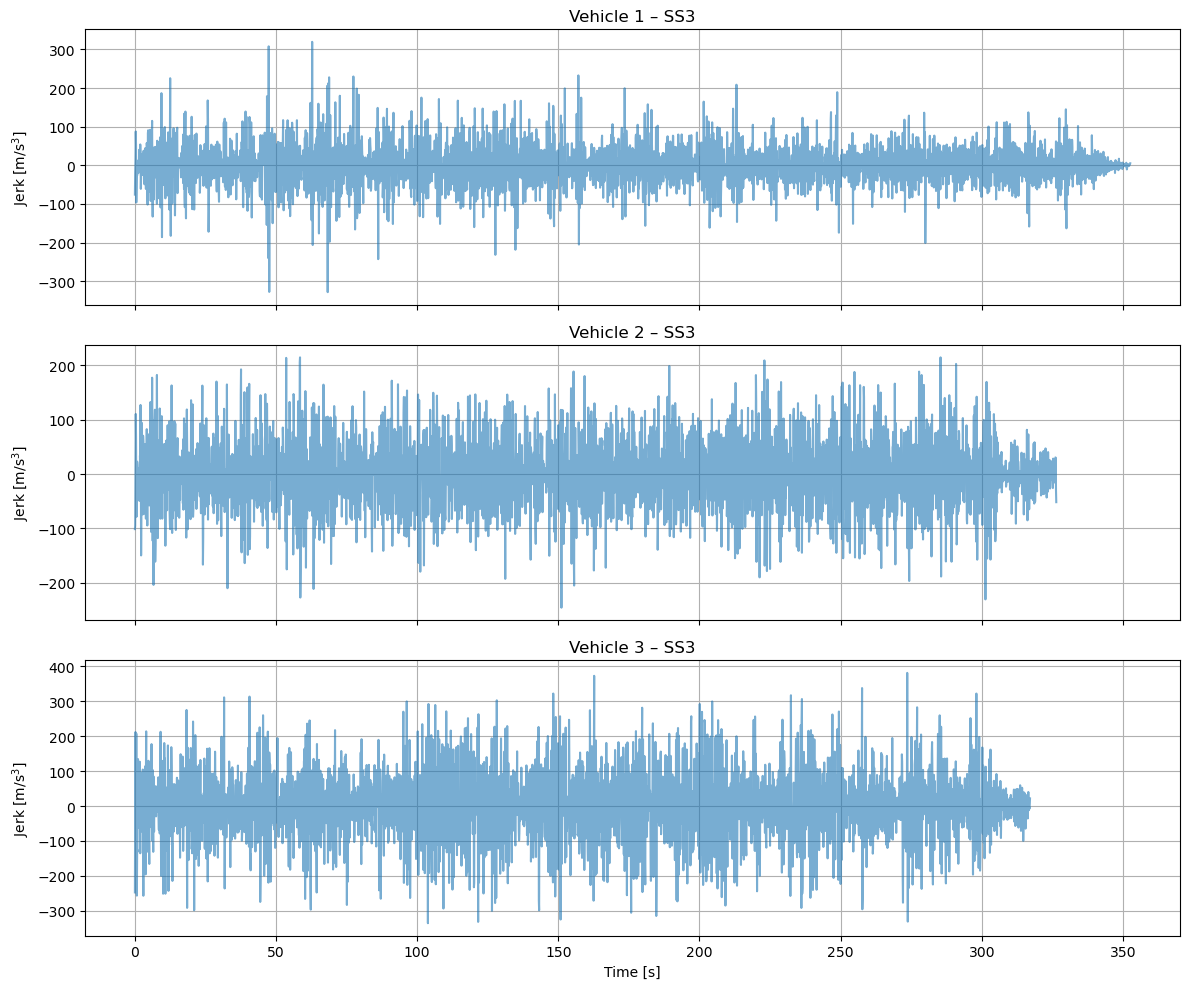

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Vehicle 1
axes[0].plot(ss3_v1["time_rel"], ss3_v1["jerk"], alpha=0.6)
axes[0].set_ylabel(r"Jerk [$\mathrm{m/s^3}$]")
axes[0].set_title("Vehicle 1 – SS3")
axes[0].grid()

# Vehicle 2
axes[1].plot(ss3_v2["time_rel"], ss3_v2["jerk"], alpha=0.6)
axes[1].set_ylabel(r"Jerk [$\mathrm{m/s^3}$]")
axes[1].set_title("Vehicle 2 – SS3")
axes[1].grid()

# Vehicle 3
axes[2].plot(ss3_v3["time_rel"], ss3_v3["jerk"], alpha=0.6)
axes[2].set_ylabel(r"Jerk [$\mathrm{m/s^3}$]")
axes[2].set_xlabel("Time [s]")
axes[2].set_title("Vehicle 3 – SS3")
axes[2].grid()

plt.tight_layout()
plt.show()

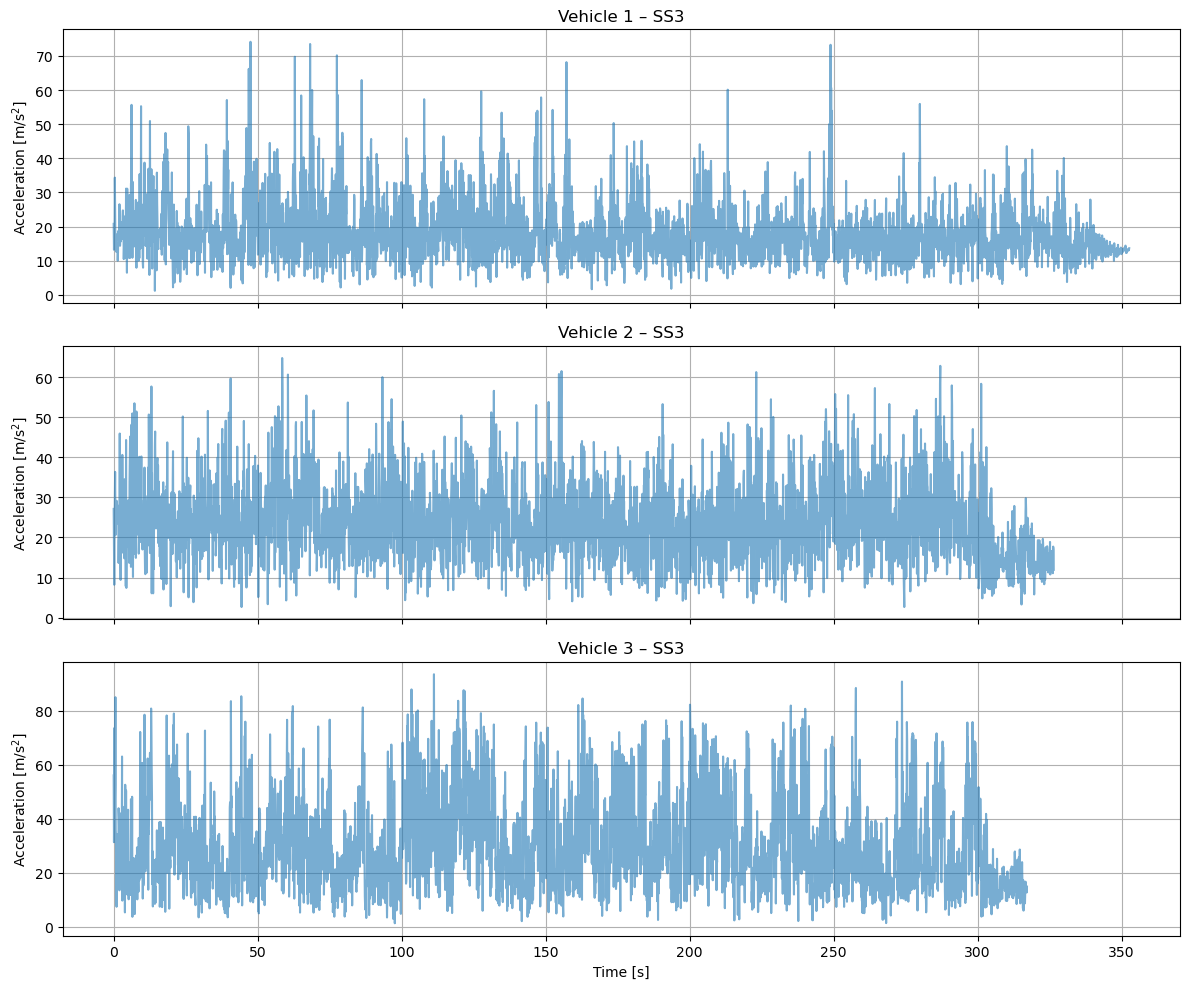

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Vehicle 1
axes[0].plot(ss3_v1["time_rel"], ss3_v1["acc_magnitude_no_gravity"], alpha=0.6)
axes[0].set_ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
axes[0].set_title("Vehicle 1 – SS3")
axes[0].grid()

# Vehicle 2
axes[1].plot(ss3_v2["time_rel"], ss3_v2["acc_magnitude_no_gravity"], alpha=0.6)
axes[1].set_ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
axes[1].set_title("Vehicle 2 – SS3")
axes[1].grid()

# Vehicle 3
axes[2].plot(ss3_v3["time_rel"], ss3_v3["acc_magnitude_no_gravity"], alpha=0.6)
axes[2].set_ylabel(r"Acceleration [$\mathrm{m/s^2}$]")
axes[2].set_xlabel("Time [s]")
axes[2].set_title("Vehicle 3 – SS3")
axes[2].grid()

plt.tight_layout()
plt.show()

In [48]:
ss3_v1.to_csv("ss3_v1_final.csv", index=False)
ss3_v2.to_csv("ss3_v2_final.csv", index=False)
ss3_v3.to_csv("ss3_v3_final.csv", index=False)

In [50]:
trajectory1 = pd.read_csv("vehicle1_SS3_trajectory.csv")
trajectory2 = pd.read_csv("vehicle2_SS3_trajectory.csv")
trajectory3 = pd.read_csv("vehicle3_SS3_trajectory.csv")

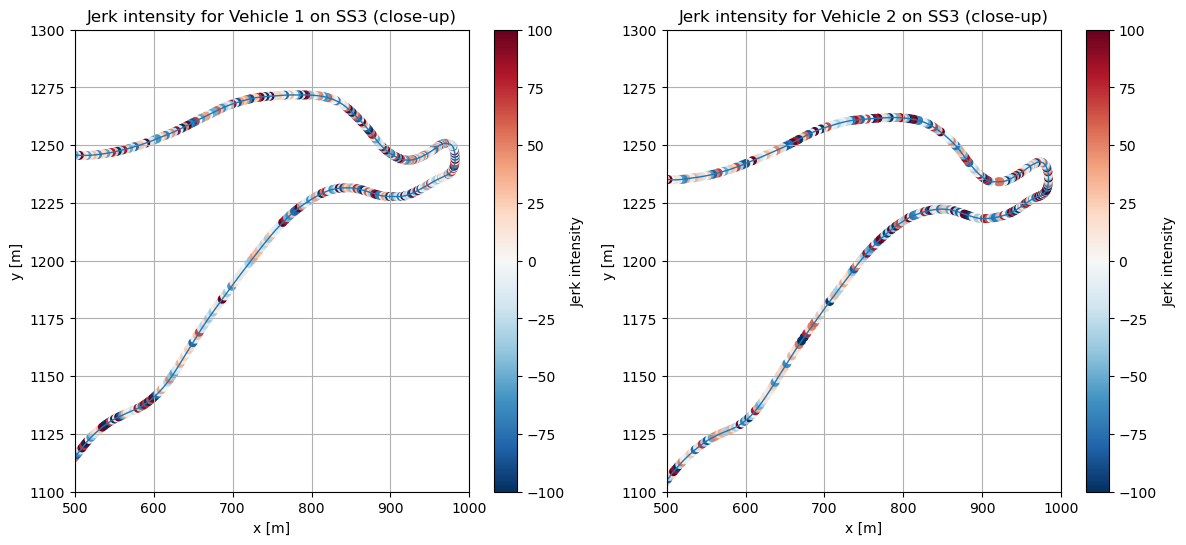

In [88]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(trajectory1["x"], trajectory1["y"], linewidth = 1)

scatter = plt.scatter(trajectory1["x"], trajectory1["y"], c=ss3_v1["jerk"], cmap="RdBu_r", vmin = -100, vmax = 100, s=30)
plt.colorbar(scatter, label="Jerk intensity")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Jerk intensity for Vehicle 1 on SS3 (close-up)")
plt.xlim(500, 1000)   
plt.ylim(1100, 1300) 
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(trajectory2["x"], trajectory2["y"], linewidth = 1)

scatter = plt.scatter(trajectory2["x"], trajectory2["y"], c=ss3_v2["jerk"], cmap="RdBu_r", vmin = -100, vmax = 100, s=30)
plt.colorbar(scatter, label="Jerk intensity")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Jerk intensity for Vehicle 2 on SS3 (close-up)")

plt.xlim(500, 1000)   
plt.ylim(1100, 1300) 

plt.grid()
plt.show()


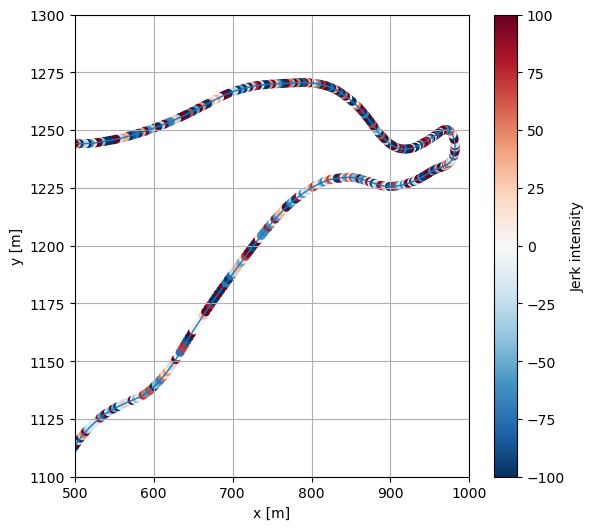

In [89]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(trajectory3["x"], trajectory3["y"], linewidth = 1)

scatter = plt.scatter(trajectory3["x"], trajectory3["y"], c=ss3_v3["jerk"], cmap="RdBu_r", vmin = -100, vmax = 100, s=30)
plt.colorbar(scatter, label="Jerk intensity")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("")

plt.xlim(500, 1000)
plt.ylim(1100, 1300)
plt.grid()
plt.show()